# Run Pipeline_ Chạy toàn bộ Task 1 -> Task 7 end-to-end

In [1]:
%load_ext autoreload
%autoreload 2

## 1. Import thư viện

In [2]:
import sys
import time
import json
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## 2. Thiết lập đường dẫn + load config + load model

In [3]:
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
sys.path.append(str(PROJECT_ROOT))

from src.pipeline import (
    load_pipeline_config, run_pipeline_on_image, draw_detections
)
from src.classifier import load_model
from src.data_loader import list_image_paths, load_config
from src.utils import show_images

params, PROJECT_ROOT, CONFIG_PATH = load_pipeline_config(PROJECT_ROOT)
CFG, _, _ = load_config(PROJECT_ROOT)
TEST_IMAGE_DIR = PROJECT_ROOT / "test"

print("Tham số pipeline đang dùng (đọc từ config.yaml):")
for task, p in params.items():
    print(f"  {task}: {p}")

MODEL_BIN_PATH   = Path(params["task6"]["model_bin_path"])
MODEL_MULTI_PATH = Path(params["task6"]["model_multi_path"])
assert MODEL_BIN_PATH.exists() and MODEL_MULTI_PATH.exists(), (
    f"Không tìm thấy model tại {MODEL_BIN_PATH} hoặc {MODEL_MULTI_PATH}. "
    f"Hãy chạy xong 06_task6_svm.ipynb trước."
)
model_bin, scaler_bin     = load_model(MODEL_BIN_PATH)
model_multi, scaler_multi = load_model(MODEL_MULTI_PATH)
print(f"Đã load Tầng 1 -> {MODEL_BIN_PATH}")
print(f"Đã load Tầng 2 -> {MODEL_MULTI_PATH}")

with open(PROJECT_ROOT / "data"/"raw"/"classes_vie.txt", "r", encoding="utf-8") as f:
    CLASS_NAMES = [line.strip() for line in f if line.strip()]
print(f"Đã load {len(CLASS_NAMES)} tên lớp tiếng Việt")

Tham số pipeline đang dùng (đọc từ config.yaml):
  task1: {'kernel_size': 3, 'tile_grid_size': (8, 8)}
  task2: {'debug_mask_set_number': 1, 'union_hsv_sets': True, 'include_achromatic': False, 'achromatic_dilate_ksize': 9, 'fill_holes': True}
  task2_union: {'nms_iou_thresh': 0.4, 'hsv_ar_range': (0.4, 2.5), 'hsv_min_extent': 0.15, 'mser_ar_range': (0.6, 1.6), 'mser_min_extent': 0.15, 'hsv_set': 1, 'mser_delta': 5, 'canny_low': 50, 'canny_high': 150}
  task3_shape: {'circle': {'dp': 1.2, 'min_dist': 25, 'param1': 120, 'param2': 40, 'min_radius': 6, 'max_radius': 74}, 'triangle': {'approx_eps_ratio': 0.12, 'max_side_ratio': 3.0, 'min_red_ratio': 0.05, 'min_yellow_fill': 0.0, 'min_angle_deg': 12, 'min_area': 150}, 'rectangle': {'approx_eps_ratio': 0.1, 'min_extent': 0.65, 'max_aspect': 2.5, 'angle_tol': 45, 'min_area': 200}}
  task4: {'min_w': 12, 'min_h': 12, 'min_aspect_ratio': 0.4, 'max_aspect_ratio': 1.9, 'resize': (64, 64), 'nms_iou_threshold': 0.4}
  task5: {'hog_params': {'orient

## 3. Demo trên ảnh mẫu ngẫu nhiên từ thư mục ảnh test

Demo trên 10 ảnh mẫu ngẫu nhiên từ c:\Users\lengo\Downloads\Python\Computer Vision\Project\test


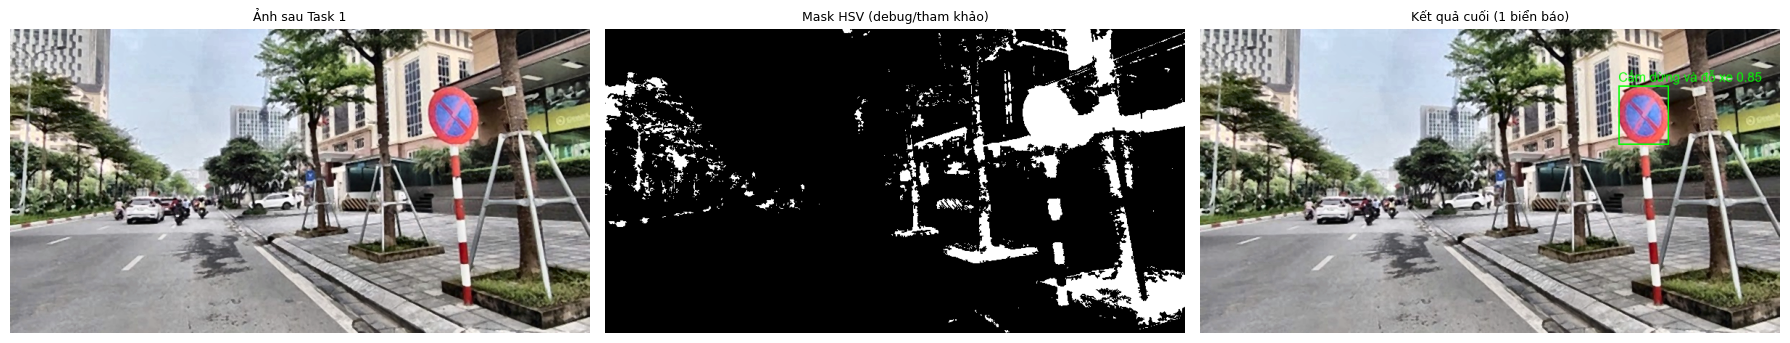

Z7881058327332_Df1d8.jpg: 1 phát hiện, thời gian xử lý = 5.392s


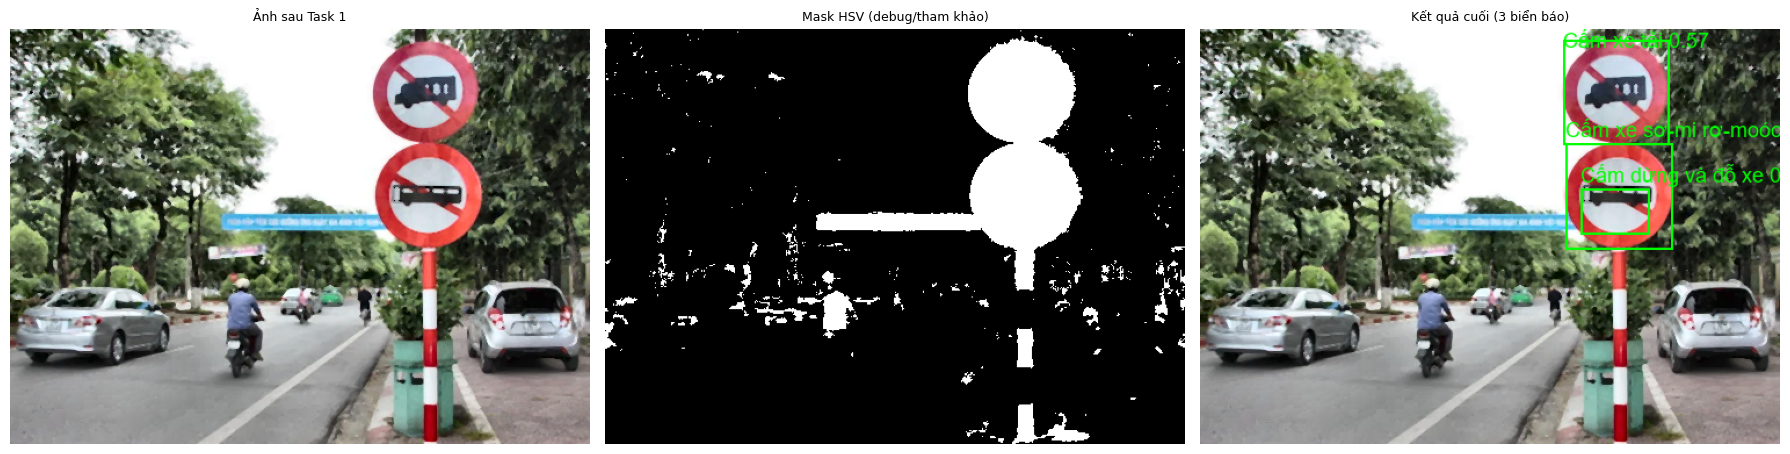

149897985256124-c.png: 3 phát hiện, thời gian xử lý = 2.791s


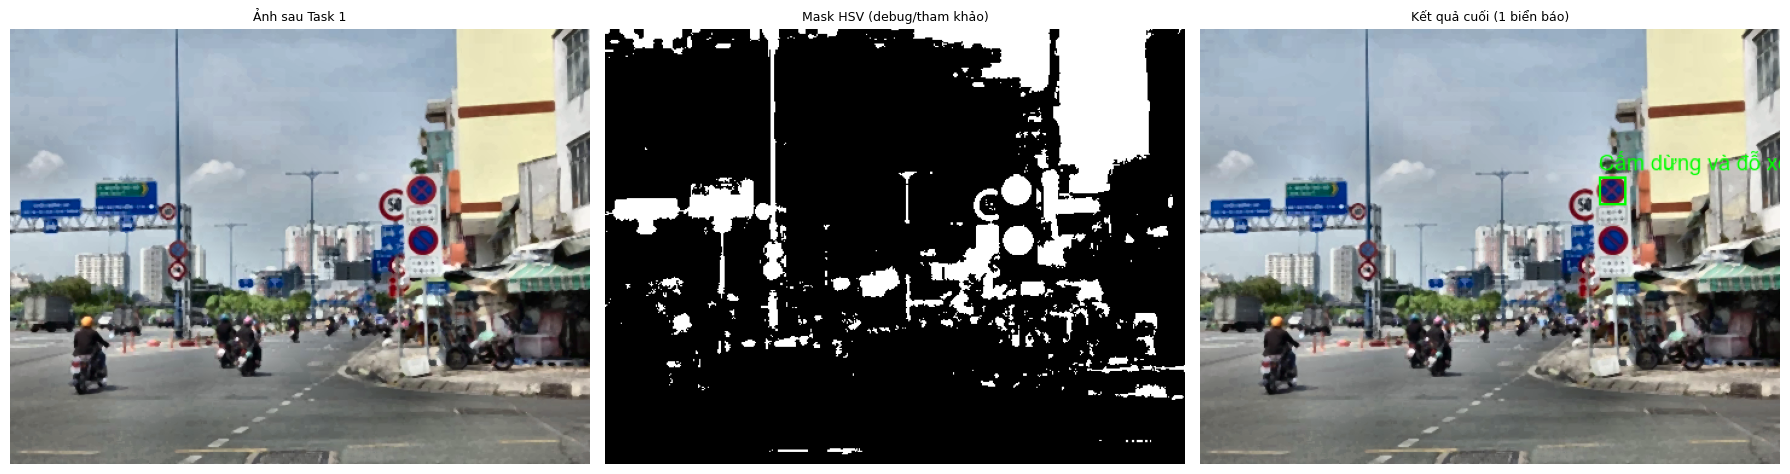

img-bgt-2021-nhieu-bien-bao-dat-canh-nhau-che-khuat-nhau-tao-cam-giac-lon-xon-kho-nhin-cho-nguoi-tham-gia-giao-thong-1622120330-width1280height960.jpg: 1 phát hiện, thời gian xử lý = 1.720s


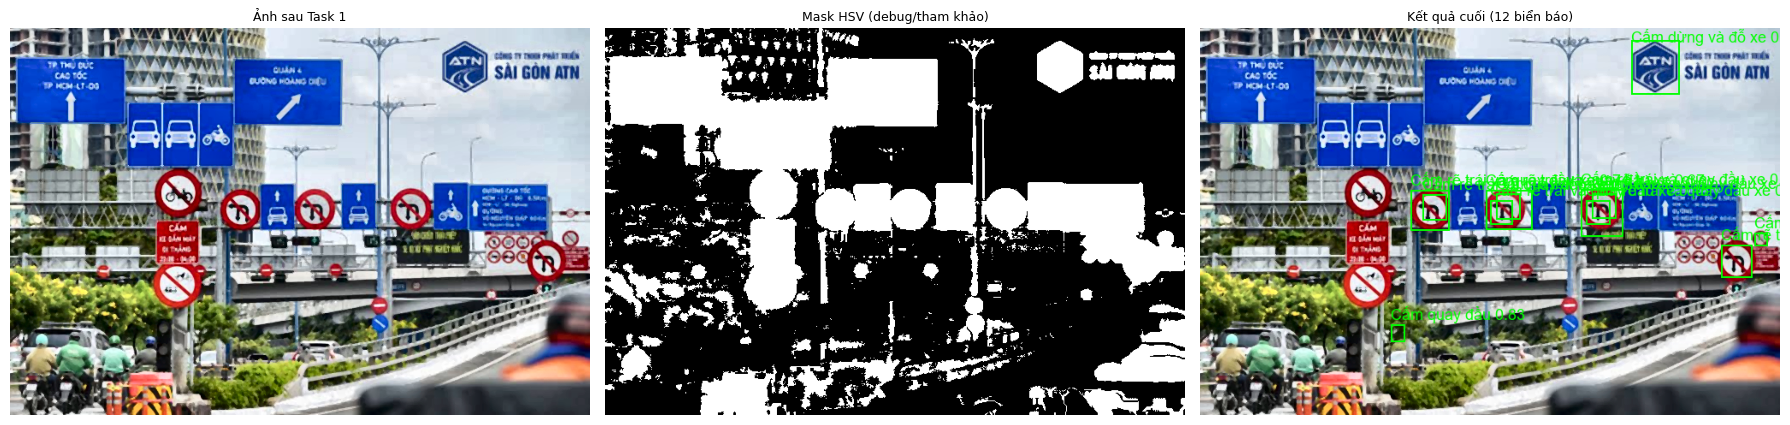

images (2).jpg: 12 phát hiện, thời gian xử lý = 5.223s


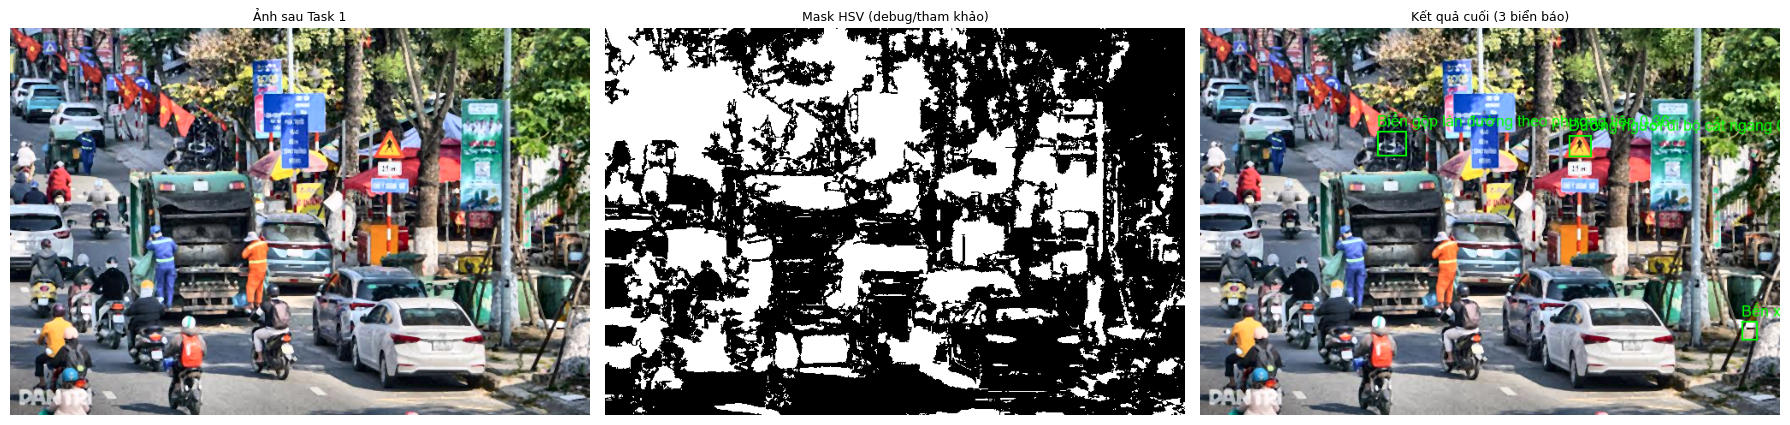

images (9).jpg: 3 phát hiện, thời gian xử lý = 8.162s


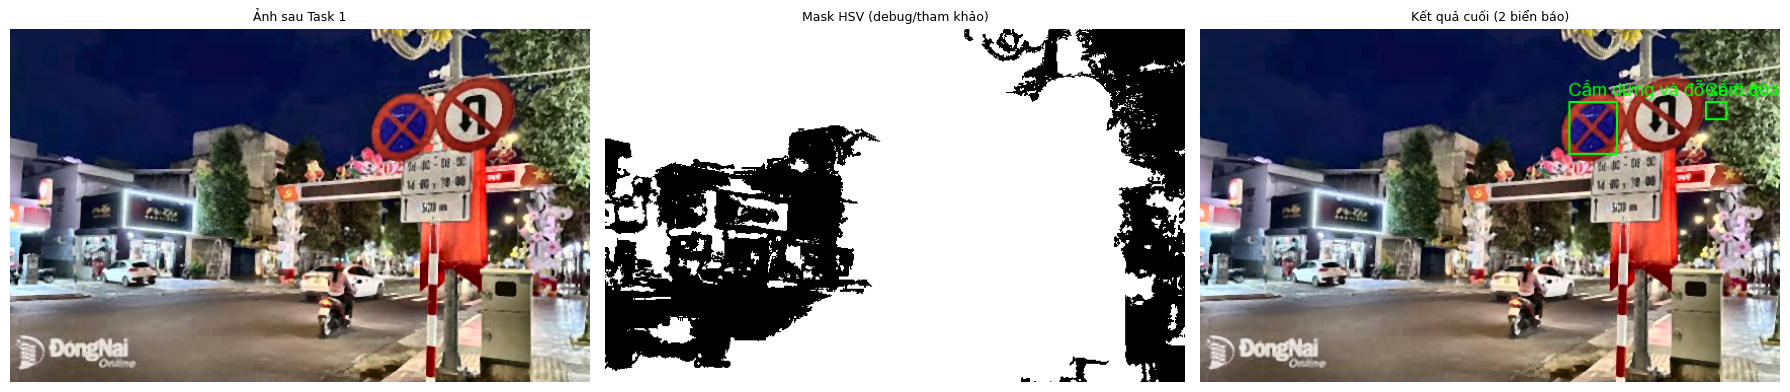

images (5).jpg: 2 phát hiện, thời gian xử lý = 3.445s


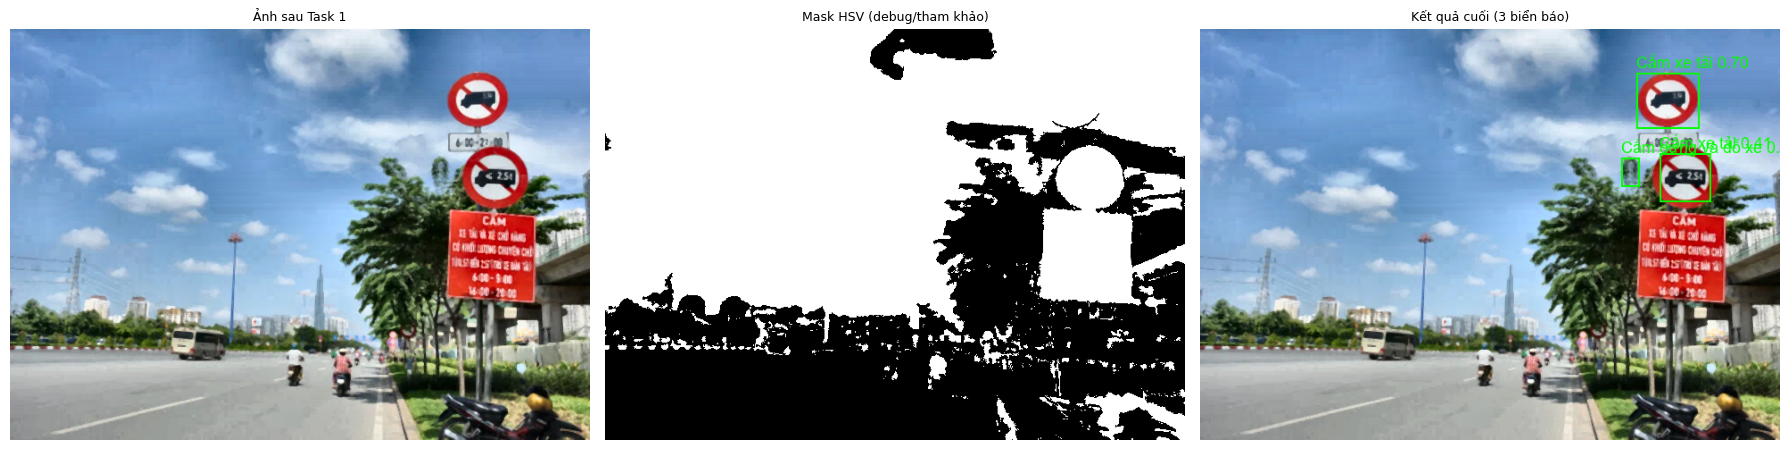

bang-cam-xe-tai.png: 3 phát hiện, thời gian xử lý = 2.489s


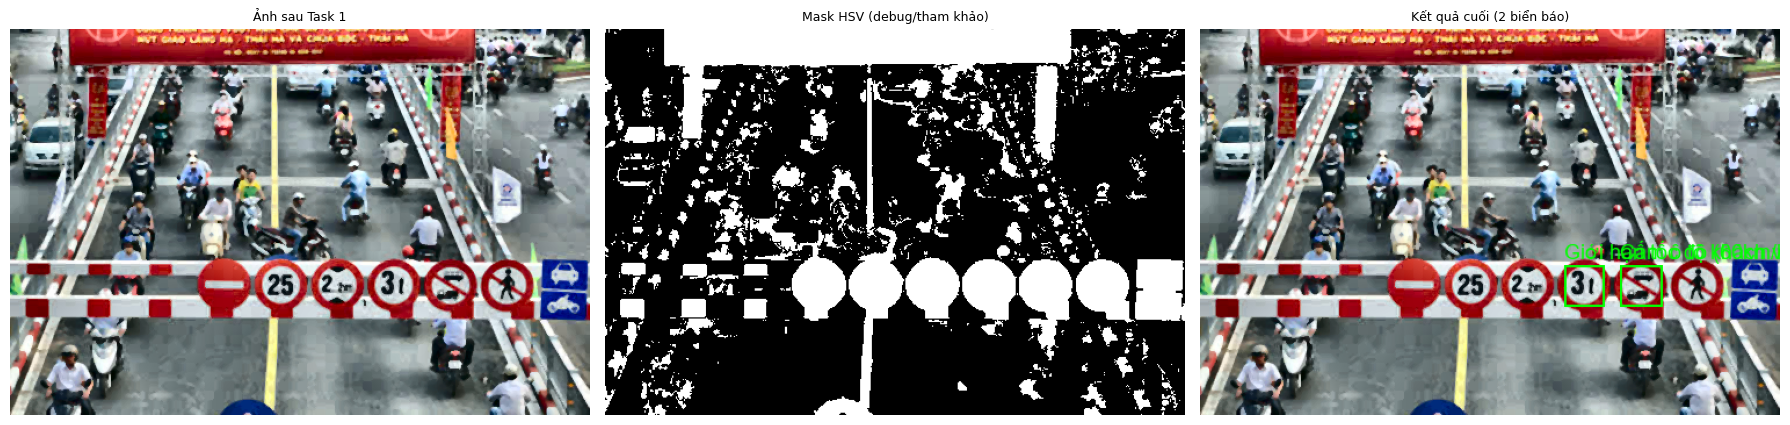

1784009142279_277029285775734052_3201945193797643667_ebdfd5dd8f25a1522dfa4022ac893f8a.jpg: 2 phát hiện, thời gian xử lý = 4.729s


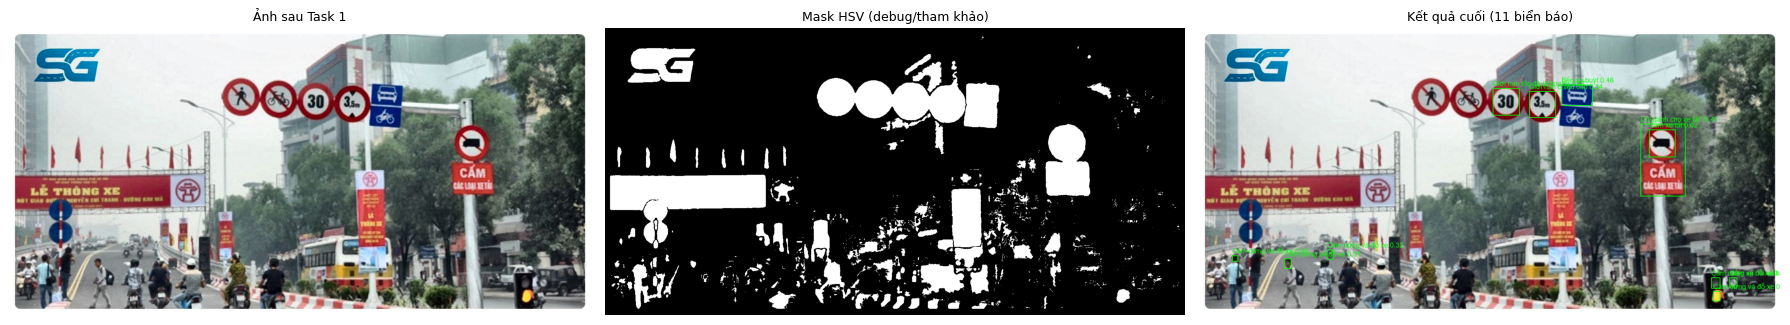

bien-bao-cam-1.jpg: 11 phát hiện, thời gian xử lý = 9.517s


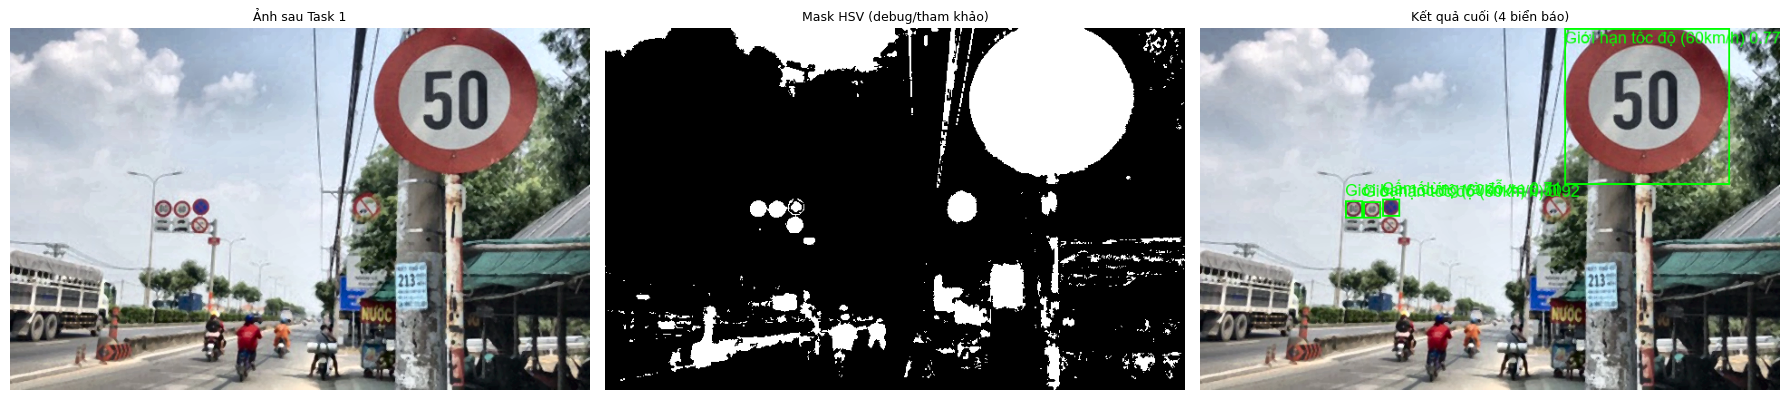

photo1649907613849-1649907613944498924209.png: 4 phát hiện, thời gian xử lý = 3.817s


In [5]:
random.seed(56)
all_images = list_image_paths(TEST_IMAGE_DIR)
assert len(all_images) > 0, f"Không tìm thấy ảnh nào trong {TEST_IMAGE_DIR}"

sample_paths = random.sample(all_images, min(10, len(all_images)))
print(f"Demo trên {len(sample_paths)} ảnh mẫu ngẫu nhiên từ {TEST_IMAGE_DIR}")

for path in sample_paths:
    t0 = time.time()
    enhanced, mask_debug, detections = run_pipeline_on_image(
        path, project_root=PROJECT_ROOT,
        model_bin=model_bin, scaler_bin=scaler_bin,
        model_multi=model_multi, scaler_multi=scaler_multi,
    )
    elapsed = time.time() - t0

    result_img = draw_detections(enhanced, detections, class_names=CLASS_NAMES)
    show_images(
        [enhanced, cv2.cvtColor(mask_debug, cv2.COLOR_GRAY2BGR), result_img],
        ["Ảnh sau Task 1", "Mask HSV (debug/tham khảo)", f"Kết quả cuối ({len(detections)} biển báo)"],
        figsize=(18, 5)
    )
    print(f"{path.name}: {len(detections)} phát hiện, thời gian xử lý = {elapsed:.3f}s")

# 4. Đánh giá thời gian xử lý ảnh

In [ ]:
processing_times = []
for path in all_images:
    t0 = time.time()
    _, _, detections = run_pipeline_on_image(
        path, project_root=PROJECT_ROOT,
        model_bin=model_bin, scaler_bin=scaler_bin,
        model_multi=model_multi, scaler_multi=scaler_multi,
    )
    processing_times.append(time.time() - t0)

processing_times = np.array(processing_times)
print(f"Tổng số ảnh: {len(processing_times)}")
print(f"Thời gian trung bình/ảnh: {processing_times.mean():.3f}s")
print(f"Trung vị: {np.median(processing_times):.3f}s")
print(f"Nhỏ nhất/Lớn nhất: {processing_times.min():.3f}s / {processing_times.max():.3f}s")
print(f"FPS trung bình ước tính: {1.0 / processing_times.mean():.2f} ảnh/giây")

Tổng số ảnh: 32
Thời gian trung bình/ảnh: 6.716s
Trung vị: 2.351s
Nhỏ nhất/Lớn nhất: 0.611s / 98.581s
FPS trung bình ước tính: 0.15 ảnh/giây
